In [1]:
import warnings
warnings.filterwarnings('ignore')

# Basic imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
# Time series tools
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing, Holt
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [6]:
import pmdarima as pm
from prophet import Prophet
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU

In [7]:
def load_co2():
    """Load monthly CO2 dataset from statsmodels and clean it."""
    d = sm.datasets.co2.load_pandas().data
    # dataset is monthly with NaNs; convert index to datetime and resample monthly
    d = d['co2'].resample('MS').mean()
    d = d.fillna(method='ffill')  # simple imputation for demo
    d.index = pd.to_datetime(d.index)
    d.name = 'co2'
    return d

In [8]:
def train_test_split_series(series, test_periods=36):
    train = series.iloc[:-test_periods]
    test = series.iloc[-test_periods:]
    return train, test

In [9]:
def print_adf(series, title='Series'):
    print(f"--- Augmented Dickey-Fuller test for {title} ---")
    res = adfuller(series.dropna())
    print(f"ADF statistic: {res[0]:.4f}, p-value: {res[1]:.4f}")
    for k,v in res[4].items():
        print(f"  Critical value ({k}): {v:.4f}")
    print()

In [10]:
def plot_series(series, title='Series', figsize=(12,4)):
    plt.figure(figsize=figsize)
    series.plot(marker='.', linewidth=1)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [11]:
def evaluate_forecast(y_true, y_pred, name='model'):
    rmse = sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name} --> RMSE: {rmse:.4f}, MAE: {mae:.4f}")
    return {'model': name, 'rmse': rmse, 'mae': mae}

Time series loaded. Range: 1958-03-01 to 2001-12-01 n= 526


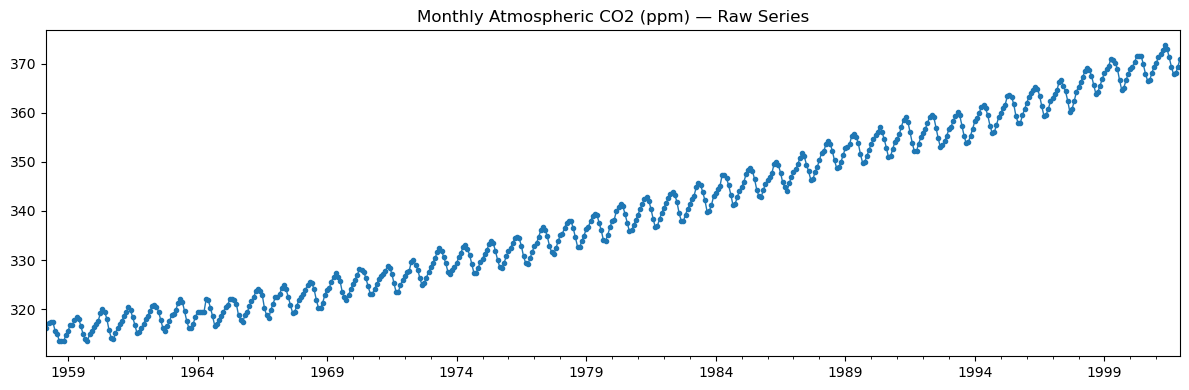

In [12]:
ts = load_co2()
print("Time series loaded. Range:", ts.index.min().date(), "to", ts.index.max().date(), "n=", len(ts))
plot_series(ts, "Monthly Atmospheric CO2 (ppm) — Raw Series")

In [13]:
# Summary statistics
display(ts.describe())

count    526.000000
mean     339.613577
std       17.122511
min      313.400000
25%      324.025000
50%      337.912500
75%      354.537500
max      373.800000
Name: co2, dtype: float64

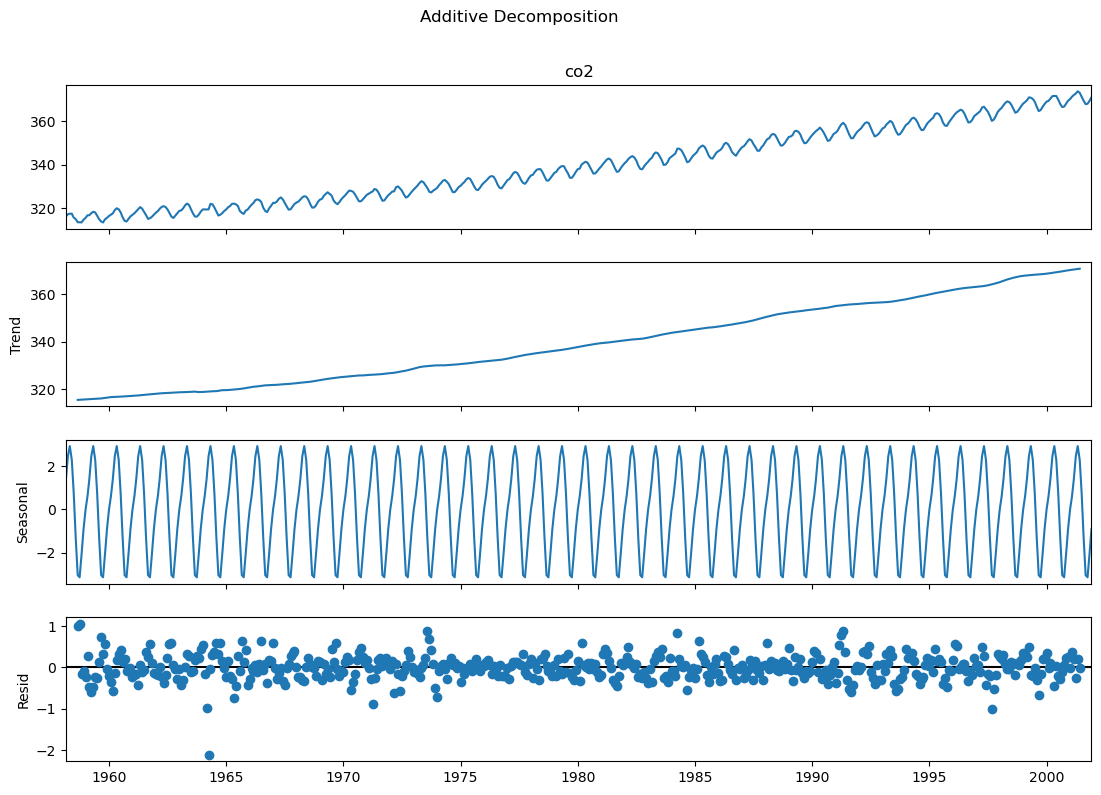

In [14]:
# Seasonal decomposition (additive)
decomp = seasonal_decompose(ts, model='additive', period=12)
fig = decomp.plot()
fig.set_size_inches(12,8)
plt.suptitle('Additive Decomposition', y=1.02)
plt.show()

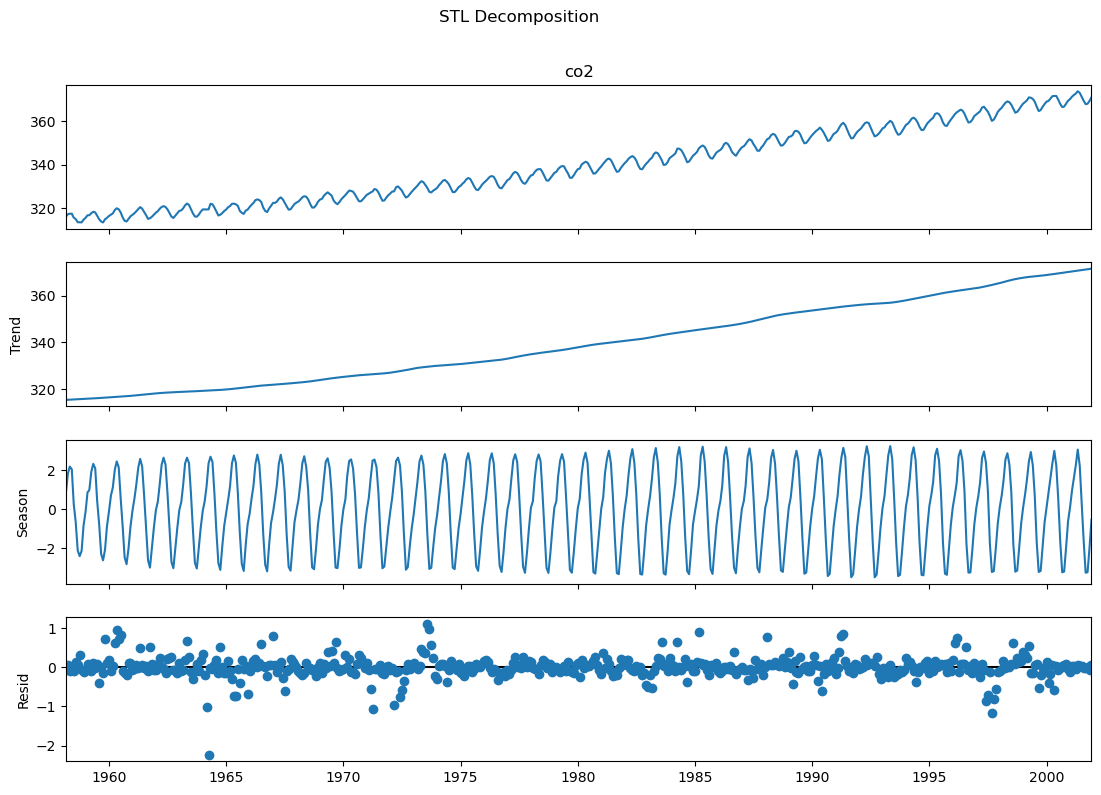

In [16]:
# STL decomposition (robust)
stl = sm.tsa.STL(ts, period=12, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(12,8)
plt.suptitle('STL Decomposition', y=1.02)
plt.show()

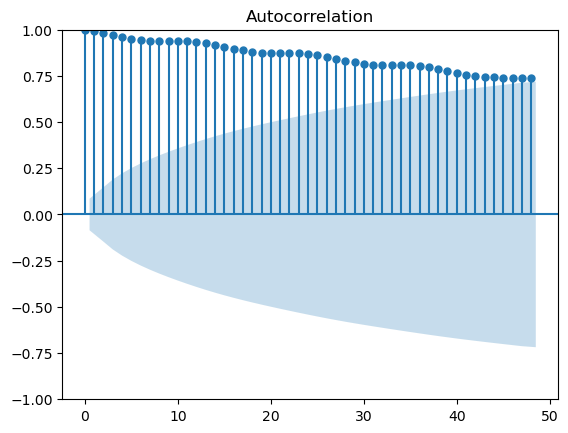

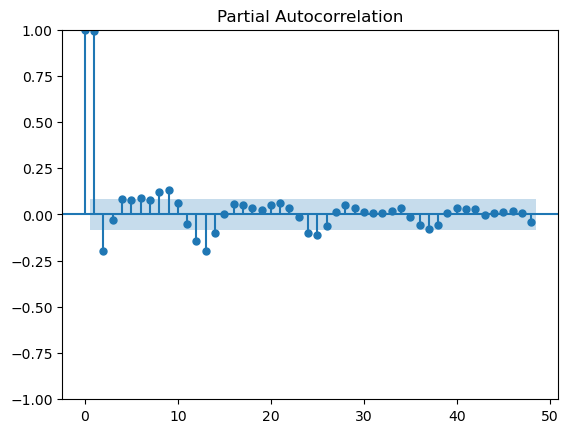

In [17]:
# ACF / PACF
plot_acf(ts.dropna(), lags=48)
plt.show()
plot_pacf(ts.dropna(), lags=48, method='ywm')
plt.show()

In [18]:
# Stationarity
print_adf(ts, 'CO2 - raw series')

--- Augmented Dickey-Fuller test for CO2 - raw series ---
ADF statistic: 2.2848, p-value: 0.9989
  Critical value (1%): -3.4432
  Critical value (5%): -2.8672
  Critical value (10%): -2.5698



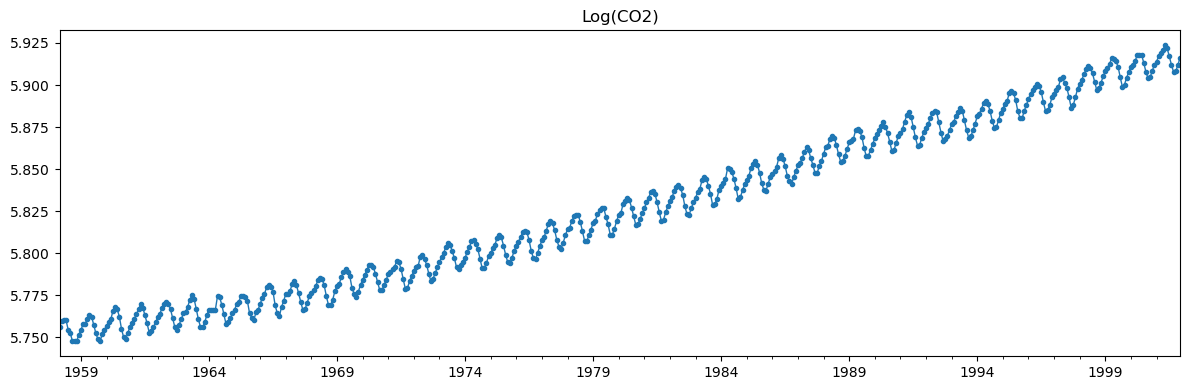

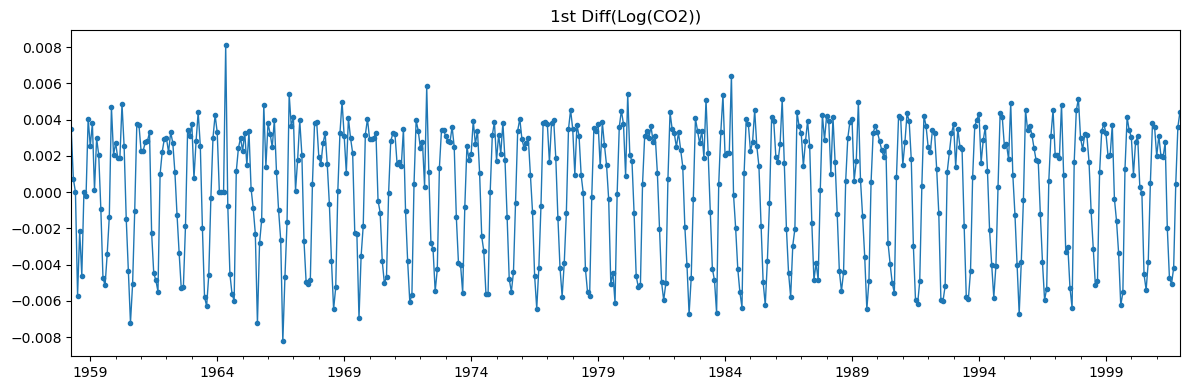

--- Augmented Dickey-Fuller test for 1st Diff(Log(CO2)) ---
ADF statistic: -5.1177, p-value: 0.0000
  Critical value (1%): -3.4434
  Critical value (5%): -2.8673
  Critical value (10%): -2.5698



In [19]:
# Log transform and differencing for stationarity demo
ts_log = np.log(ts)
plot_series(ts_log, 'Log(CO2)')
ts_log_diff = ts_log.diff().dropna()
plot_series(ts_log_diff, '1st Diff(Log(CO2))')
print_adf(ts_log_diff, '1st Diff(Log(CO2))')

Train length: 490 Test length: 36
SES --> RMSE: 3.3364, MAE: 2.8393


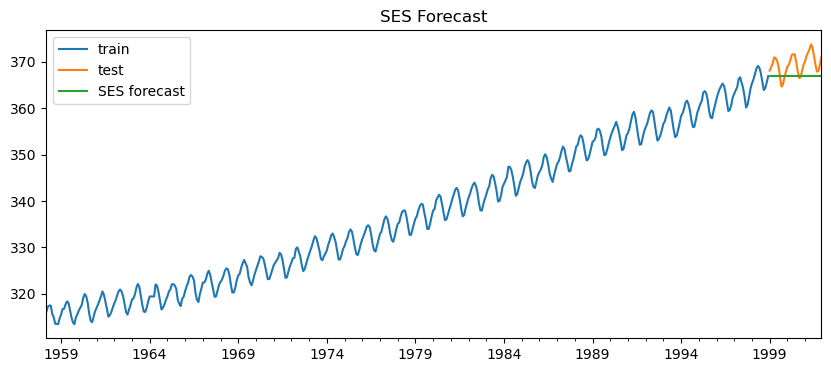

In [20]:
#####################
# Exponential smoothing family
#####################
train, test = train_test_split_series(ts, test_periods=36)
print("Train length:", len(train), "Test length:", len(test))

# 1) Simple Exponential Smoothing (SES)
ses = SimpleExpSmoothing(train).fit(optimized=True)
ses_forecast = ses.forecast(len(test))
evaluate_forecast(test, ses_forecast, 'SES')
plt.figure(figsize=(10,4))
train.plot(label='train'); test.plot(label='test'); ses_forecast.plot(label='SES forecast')
plt.legend(); plt.title('SES Forecast')
plt.show()

Holt Linear --> RMSE: 26.6959, MAE: 22.8826


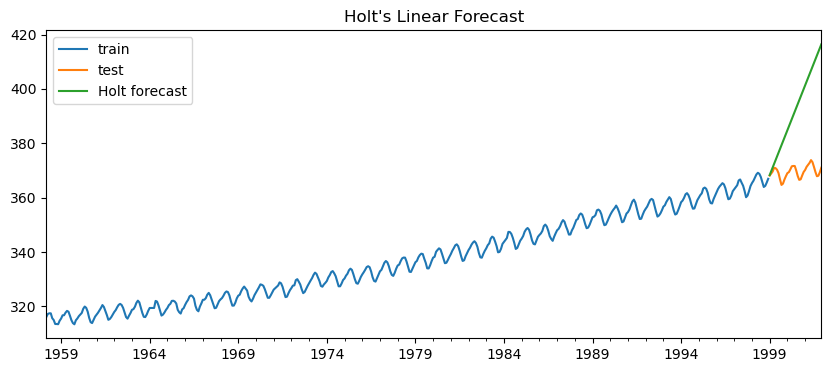

In [21]:
# 2) Holt's linear trend
holt = Holt(train).fit(optimized=True)
holt_forecast = holt.forecast(len(test))
evaluate_forecast(test, holt_forecast, 'Holt Linear')
plt.figure(figsize=(10,4))
train.plot(label='train'); test.plot(label='test'); holt_forecast.plot(label='Holt forecast')
plt.legend(); plt.title("Holt's Linear Forecast")
plt.show()

Holt-Winters Additive --> RMSE: 0.8888, MAE: 0.8103
Holt-Winters Multiplicative --> RMSE: 1.0901, MAE: 0.9984


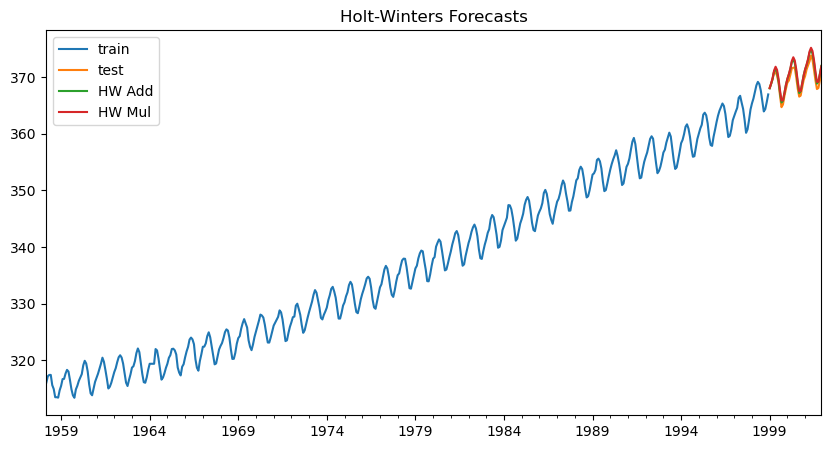

In [22]:
# 3) Holt-Winters (additive & multiplicative seasonal)
hw_add = ExponentialSmoothing(train, seasonal='add', trend='add', seasonal_periods=12).fit(optimized=True)
hw_mul = ExponentialSmoothing(train, seasonal='mul', trend='add', seasonal_periods=12).fit(optimized=True)
hw_add_f = hw_add.forecast(len(test))
hw_mul_f = hw_mul.forecast(len(test))
evaluate_forecast(test, hw_add_f, 'Holt-Winters Additive')
evaluate_forecast(test, hw_mul_f, 'Holt-Winters Multiplicative')
plt.figure(figsize=(10,5))
train.plot(label='train'); test.plot(label='test'); hw_add_f.plot(label='HW Add'); hw_mul_f.plot(label='HW Mul')
plt.legend(); plt.title('Holt-Winters Forecasts')
plt.show()

In [25]:
def hw_grid_search(train, test, seasonal='add', trend='add', seasonal_periods=12):
    best = None
    results = []
    alphas = [0.2, 0.4, 0.6, 0.8]  # None uses optimized True
    betas = [0.0, 0.1, 0.2]
    gammas = [0.0, 0.1, 0.3]
    for a in alphas:
        for b in betas:
            for g in gammas:
                try:
                    model = ExponentialSmoothing(train, seasonal=seasonal, trend=trend, seasonal_periods=seasonal_periods)
                    fit = model.fit(smoothing_level=a, smoothing_slope=b, smoothing_seasonal=g, optimized=(a is None))
                    pred = fit.forecast(len(test))
                    rmse = sqrt(mean_squared_error(test, pred))
                    results.append({'alpha':a,'beta':b,'gamma':g,'rmse':rmse})
                    if best is None or rmse < best['rmse']:
                        best = {'alpha':a,'beta':b,'gamma':g,'rmse':rmse,'model':fit}
                except Exception as e:
                    continue
    resdf = pd.DataFrame(results).sort_values('rmse').reset_index(drop=True)
    return best, resdf

In [26]:
best_hw, hw_results = hw_grid_search(train, test, seasonal='add', trend='add', seasonal_periods=12)
print("Best HW:", best_hw['alpha'], best_hw['beta'], best_hw['gamma'], "RMSE:", best_hw['rmse'])
display(hw_results.head())

Best HW: 0.8 0.2 0.1 RMSE: 0.7456126723112284


,alpha,beta,gamma,rmse
0,0.8,0.2,0.1,0.745613
1,0.6,0.2,0.3,0.920266
2,0.8,0.0,0.0,1.147629
3,0.6,0.2,0.1,1.155625
4,0.8,0.1,0.1,1.245889


Running pmdarima auto_arima (may take some time)...
Auto ARIMA order: (0, 1, 3) seasonal_order: (1, 0, 1, 12)
pmdarima_auto_arima --> RMSE: 0.9712, MAE: 0.8866


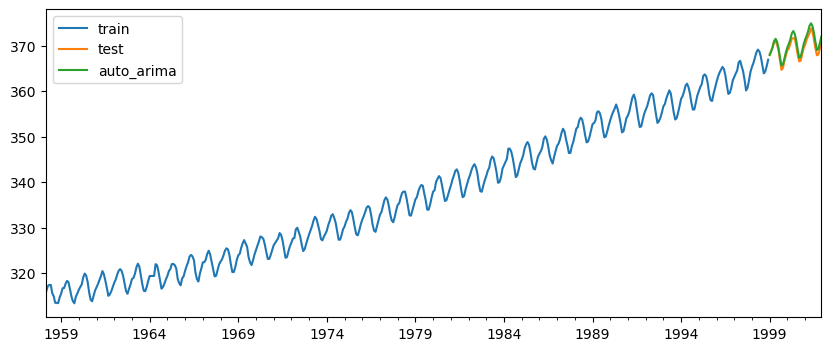

In [27]:
print("Running pmdarima auto_arima (may take some time)...")
auto = pm.auto_arima(train, seasonal=True, m=12, stepwise=True, suppress_warnings=True, error_action='ignore', trace=False)
print("Auto ARIMA order:", auto.order, "seasonal_order:", auto.seasonal_order)
# Forecast
arima_fore = auto.predict(n_periods=len(test))
arima_fore = pd.Series(arima_fore, index=test.index)
evaluate_forecast(test, arima_fore, 'pmdarima_auto_arima')
plt.figure(figsize=(10,4)); train.plot(label='train'); test.plot(label='test'); arima_fore.plot(label='auto_arima'); plt.legend(); plt.show()

C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Sreekanth\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: Conver

Best SARIMAX by AIC: (2, 0, 1) (1, 1, 1, 12) AIC: 272.61274815474235
SARIMAX_best --> RMSE: 1.4809, MAE: 1.3438


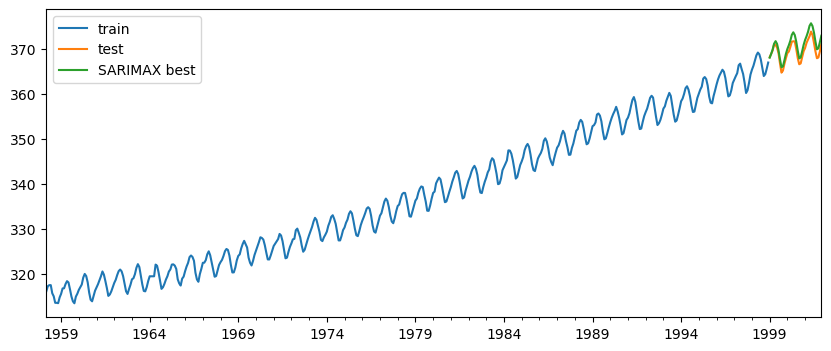

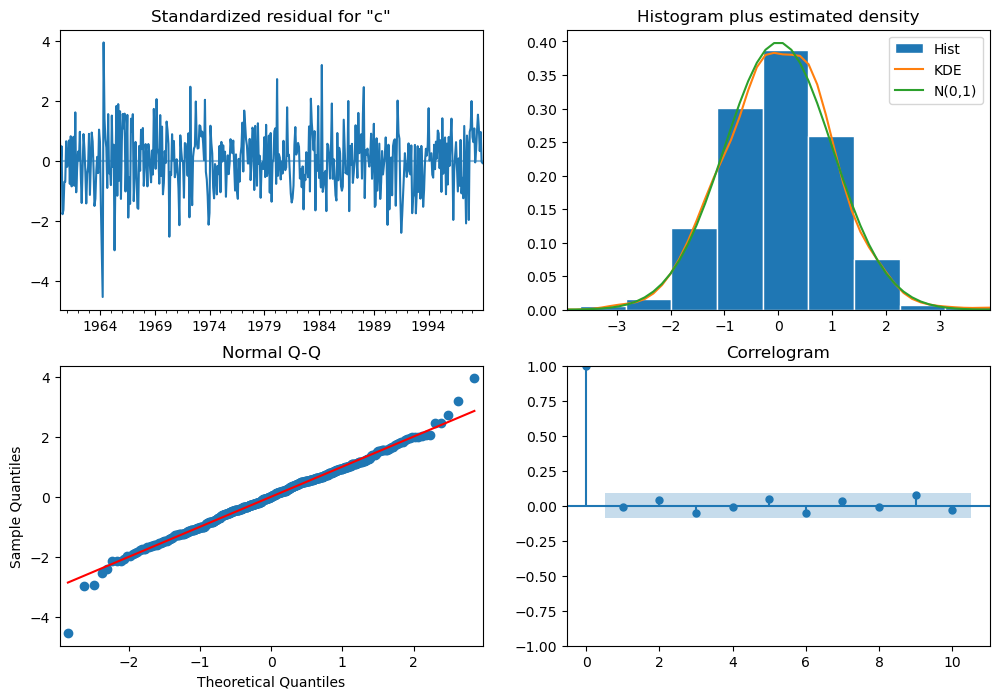

In [28]:
import itertools
p = q = range(0,3)
d = range(0,2)
pdq = list(itertools.product(p,d,q))
seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(range(0,2), range(0,2), range(0,2)))]

best_aic = np.inf
best_order = None
best_seasonal = None
best_model = None

for order in pdq:
    for seasonal in seasonal_pdq:
        try:
            mod = SARIMAX(train, order=order, seasonal_order=seasonal, enforce_stationarity=False, enforce_invertibility=False)
            res = mod.fit(disp=False)
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = order
                best_seasonal = seasonal
                best_model = res
        except Exception as e:
            continue

print("Best SARIMAX by AIC:", best_order, best_seasonal, "AIC:", best_aic)
# Forecast with best SARIMAX
sarima_fore = best_model.get_forecast(steps=len(test)).predicted_mean
evaluate_forecast(test, sarima_fore, 'SARIMAX_best')
plt.figure(figsize=(10,4)); train.plot(label='train'); test.plot(label='test'); sarima_fore.plot(label='SARIMAX best'); plt.legend(); plt.show()

# Diagnostics
best_model.plot_diagnostics(figsize=(12,8))
plt.show()


Running Prophet...


23:45:39 - cmdstanpy - INFO - Chain [1] start processing
23:45:41 - cmdstanpy - INFO - Chain [1] done processing


Prophet --> RMSE: 0.9044, MAE: 0.8141


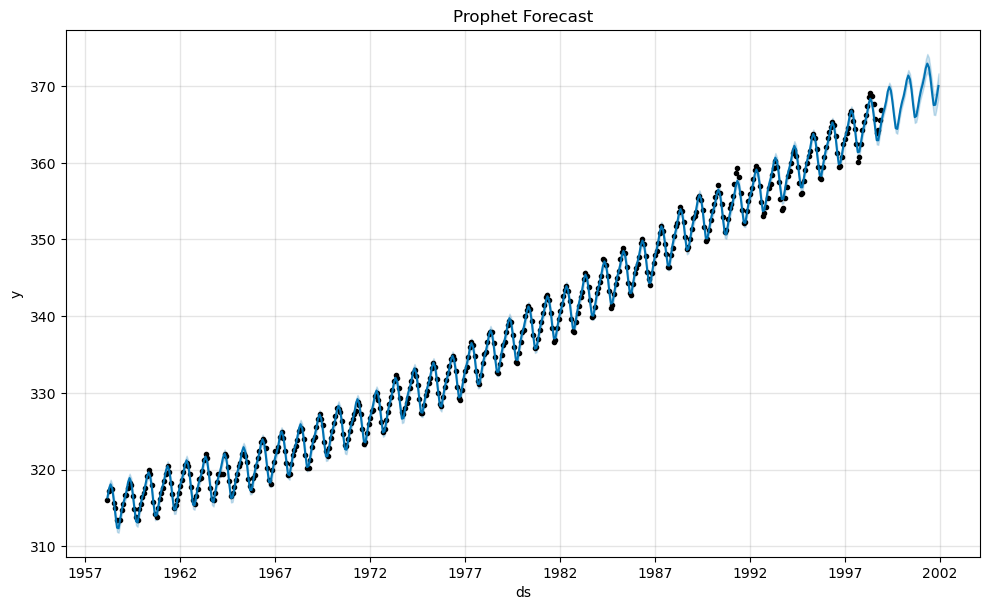

In [29]:
print("Running Prophet...")
df_prop = ts.reset_index().rename(columns={'index':'ds','co2':'y'})
# Prophet expects no missing values
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(df_prop.iloc[:-36])
future = m.make_future_dataframe(periods=36, freq='MS')
forecast = m.predict(future)
prop_fore = forecast.set_index('ds')['yhat'][-36:]
evaluate_forecast(test, prop_fore, 'Prophet')
# plot
m.plot(forecast); plt.title('Prophet Forecast'); plt.show()

In [30]:
print("Running a small LSTM demo (few epochs) — this is for demonstration; increase epochs for real use.")
from sklearn.preprocessing import MinMaxScaler
series = ts.values.reshape(-1,1)
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(series)

Running a small LSTM demo (few epochs) — this is for demonstration; increase epochs for real use.


In [37]:
def create_lagged(data, lag=12):
        X, y = [], []
        for i in range(len(data)-lag):
            X.append(data[i:i+lag, 0])
            y.append(data[i+lag, 0])
        X = np.array(X); y = np.array(y)
        X = X.reshape((X.shape[0], X.shape[1], 1))
        return X, y
lag = 36
X, y = create_lagged(series_scaled, lag=lag)
train_X, train_y = X[:-36], y[:-36]
test_X, test_y = X[-36:], y[-36:]

In [41]:
model = Sequential()
# First LSTM layer (return_sequences=True so we can stack more LSTMs)
model.add(LSTM(100, activation='tanh', return_sequences=True, 
               input_shape=(train_X.shape[1], train_X.shape[2])))
# Second LSTM layer
model.add(LSTM(50, activation='tanh', return_sequences=True))
# Third LSTM layer
model.add(LSTM(25, activation='tanh'))
# # Optional Dropout for regularization
# model.add(Dropout(0.2))
# Dense hidden layer before output
model.add(Dense(10, activation='relu'))
# Output layer (predicting one value)
model.add(Dense(1))
# Compile the model
model.compile(optimizer='adam', loss='mse')

In [42]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 36, 100)             │          40,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 36, 50)              │          30,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 25)                  │           7,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 78,871 (308.09 KB)

 Trainable params: 78,871 (308.09 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(train_X, train_y, 
                    epochs=20, 
                    batch_size=32, 
                    validation_data=(test_X, test_y), 
                    verbose=1)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 160ms/step - loss: 0.0679 - val_loss: 0.0919
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 0.0083 - val_loss: 0.0094
Epoch 3/20
14/15 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0021

In [ ]:
# forecast using last windows iterative
preds = model.predict(test_X)
preds_inv = scaler.inverse_transform(preds)
test_y_inv = scaler.inverse_transform(test_y.reshape(-1,1))
evaluate_forecast(test, pd.Series(preds_inv.flatten(), index=test.index), 'LSTM')
plt.figure(figsize=(10,4)); train.plot(label='train'); test.plot(label='test'); 
pd.Series(preds_inv.flatten(), index=test.index).plot(label='LSTM'); 
plt.legend(); 
plt.show()

In [34]:
#####################
# Summary table of model comparisons (example)
#####################
results = []
# gather earlier evaluations (some may have been printed only)
# For demonstration, recompute forecasts quickly for a few models
# SES, Holt, HW Add, SARIMAX_best, (Prophet and LSTM only if available)
models_preds = {}
models_preds['SES'] = ses_forecast
models_preds['Holt'] = holt_forecast
models_preds['HW_Add'] = hw_add_f
models_preds['HW_Mul'] = hw_mul_f
models_preds['SARIMAX_best'] = sarima_fore

In [35]:
models_preds

{'SES': 1999-01-01    366.925
 1999-02-01    366.925
 1999-03-01    366.925
 1999-04-01    366.925
 1999-05-01    366.925
 1999-06-01    366.925
 1999-07-01    366.925
 1999-08-01    366.925
 1999-09-01    366.925
 1999-10-01    366.925
 1999-11-01    366.925
 1999-12-01    366.925
 2000-01-01    366.925
 2000-02-01    366.925
 2000-03-01    366.925
 2000-04-01    366.925
 2000-05-01    366.925
 2000-06-01    366.925
 2000-07-01    366.925
 2000-08-01    366.925
 2000-09-01    366.925
 2000-10-01    366.925
 2000-11-01    366.925
 2000-12-01    366.925
 2001-01-01    366.925
 2001-02-01    366.925
 2001-03-01    366.925
 2001-04-01    366.925
 2001-05-01    366.925
 2001-06-01    366.925
 2001-07-01    366.925
 2001-08-01    366.925
 2001-09-01    366.925
 2001-10-01    366.925
 2001-11-01    366.925
 2001-12-01    366.925
 Freq: MS, dtype: float64,
 'Holt': 1999-01-01    368.300
 1999-02-01    369.675
 1999-03-01    371.050
 1999-04-01    372.425
 1999-05-01    373.800
 1999-06-01    

In [36]:
if 'arima_fore' in locals():
    models_preds['auto_arima'] = arima_fore
if Prophet is not None:
    models_preds['Prophet'] = prop_fore
if tf is not None and 'preds_inv' in locals():
    models_preds['LSTM'] = pd.Series(preds_inv.flatten(), index=test.index)

for name, pred in models_preds.items():
    res = evaluate_forecast(test, pred, name)
    results.append(res)

results_df = pd.DataFrame(results).sort_values('rmse')
print("\nModel comparison (sorted by RMSE):")
display(results_df)

SES --> RMSE: 3.3364, MAE: 2.8393
Holt --> RMSE: 26.6959, MAE: 22.8826
HW_Add --> RMSE: 0.8888, MAE: 0.8103
HW_Mul --> RMSE: 1.0901, MAE: 0.9984
SARIMAX_best --> RMSE: 1.4809, MAE: 1.3438
auto_arima --> RMSE: 0.9712, MAE: 0.8866
Prophet --> RMSE: 0.9044, MAE: 0.8141
LSTM --> RMSE: 2.5034, MAE: 2.0529

Model comparison (sorted by RMSE):


,model,rmse,mae
2,HW_Add,0.888844,0.810275
6,Prophet,0.904446,0.814142
5,auto_arima,0.971228,0.886589
3,HW_Mul,1.090115,0.998432
4,SARIMAX_best,1.480921,1.343818
7,LSTM,2.503409,2.052905
0,SES,3.336407,2.839306
1,Holt,26.695865,22.882639
